# Install any and all missing requirements (version numbers may vary we will have to check)

In [1]:
from torch.utils.data import dataset
import scipy.io as scio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math
from sklearn.metrics import mean_squared_error
import h5py
import os
import torch
import numpy.fft as fft
import nmrglue as ng
from nmrglue.fileio.bruker import scale_pdata



In [2]:
import torch
print(torch.__version__)

2.5.0+cu124


# Get newest version of nmrdenoise via pip (this is actively updating hence we must run this on jupiter or your terminal)

In [3]:
import sys
!{sys.executable} -m pip install --upgrade --no-cache-dir nmrdenoise

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install PyWavelets
!pip install "cvxpy==1.4.1"
!pip install "numpy<2.0"


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# Load in the required data files

In [5]:
#if not available download from here https://github.com/rschurko/DESPERATE/blob/master/simulations/Sn_CPMG_id.fid
Sn_CPMG_id = '../global_test_data/Sn_CPMG_id.fid'
bruker_dir_2 = "../global_test_data/ML_2024_sept2_Sucralose/2/"
bruker_dir_24 = "../global_test_data/ML_2024_sept2_Sucralose/24/"

# Initial view of the data

Optimization terminated successfully.
         Current function value: 227.034759
         Iterations: 123
         Function evaluations: 233


/home/kinkini/.local/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Amplitude')

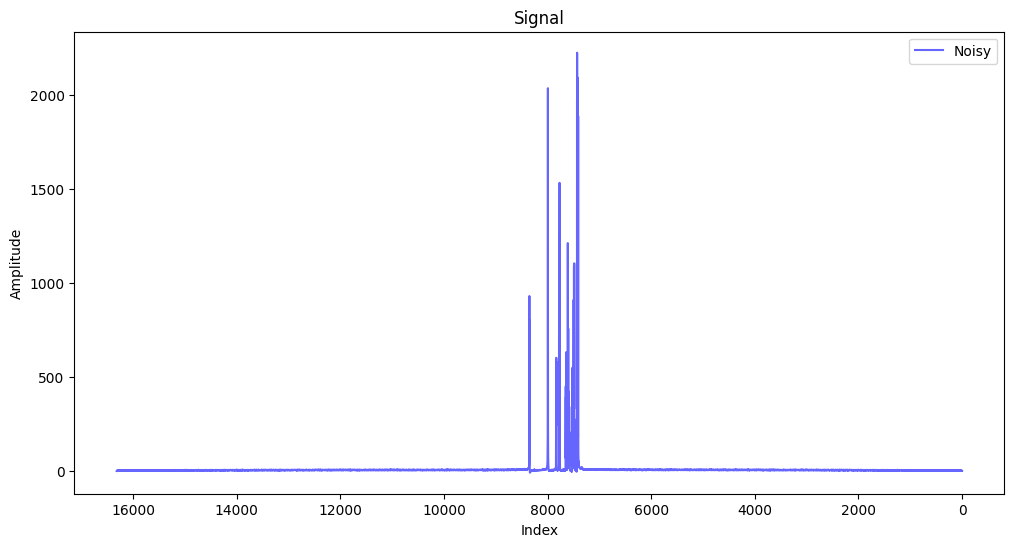

In [6]:

dic, fid = ng.bruker.read(bruker_dir_2)
fid = ng.bruker.remove_digital_filter(dic, fid)
data_high_samp = ng.process.proc_base.fft(fid)
data_high_samp = ng.process.proc_autophase.autops(data_high_samp, 'acme')  # 'acme' for auto phasing
data_high_samp = scale_pdata(dic, data_high_samp) * 2

T = np.size(data_high_samp)  # total duration in seconds
time = np.linspace(0, T, num=np.size(data_high_samp))

plt.figure(figsize=(12, 6))
plt.plot(data_high_samp, label='Noisy', color='blue', alpha=0.6)
plt.gca().invert_xaxis()
plt.legend()
plt.title('Signal')
plt.xlabel('Index')
plt.ylabel('Amplitude')

In [7]:


dic, fid = ng.bruker.read(bruker_dir_24)
fid = ng.bruker.remove_digital_filter(dic, fid)
data = ng.process.proc_base.fft(fid) 
data = ng.process.proc_autophase.autops(data, 'acme')  # auto phasing
data = scale_pdata(dic, data) * 2

fid = ng.bruker.remove_digital_filter(dic, fid)
ideal = ng.process.proc_base.fft(fid)
ideal = ng.process.proc_autophase.autops(ideal, 'acme')  
ideal = scale_pdata(dic, ideal) * 2

real_data = np.real(data)
imag_data = np.imag(data)
max_data = np.max(real_data)
min_data = np.min(real_data)


Optimization terminated successfully.
         Current function value: 11259.782937
         Iterations: 133
         Function evaluations: 256
Optimization terminated successfully.
         Current function value: 11491.261223
         Iterations: 116
         Function evaluations: 220


# Normalize and get data to a viable shape

In [8]:
# crop to multiple of 128 (some of these models are not flexible and sizes T-T)
cropped_data = real_data[:16256]
data_min = cropped_data.min()
data_max = cropped_data.max()
normalized_data = (cropped_data - data_min) / (data_max - data_min)

# Call Desperate

In [9]:
import nmrdenoise as nd

dn = nd.Desperate()
print(nd.__version__)

specrecon, coeffin, coeffs = dn.wavelet_denoise(7, cropped_data, 0, wave = 'bior2.2', threshold = 'mod', alpha = 0)


0.3.6


# Call AE denoise

In [10]:
ae = nd.AE_denoise()
autoencoder_path = ae.load_denoising_checkpoint(model_name="autoencoder_20000_bruker_ver_135_percent_noise_with_noshuffle_v4_rm_spikelets_with_lb_5.pt")
ae_denoised_data, confidence = ae.denoise_component(cropped_data, autoencoder_path)

Loading checkpoint from: /home/kinkini/.local/lib/python3.11/site-packages/nmrdenoise/checkpoints/autoencoder_20000_bruker_ver_135_percent_noise_with_noshuffle_v4_rm_spikelets_with_lb_5.pt
Autoencoder model loaded successfully.


/home/kinkini/.local/lib/python3.11/site-packages/nmrdenoise/core.py:166: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load(autoencoder_pa

# Call LD net

In [11]:
#shape data to be used in LD net
cropped_data_2 = normalized_data.squeeze()[::]  
fn= len(cropped_data_2)
cropped_data_reform = cropped_data_2.reshape(1, fn)

In [12]:
# LD net requires us to perform the normalization step wheras the pevious algorithms have this in-built

ld_system = nd.LD_net()
output_ld = ld_system.test(cropped_data_reform, fn)

# plt.figure(1), plt.plot(np.squeeze(cropped_data_reform))
# plt.figure(2), plt.plot(output)

/home/kinkini/.local/lib/python3.11/site-packages/nmrdenoise/core.py:761: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net = torch.load(model_dir, map_location='cpu')


Convert x-axis points to frequency

In [13]:
frq, real_data, imag_data =  ae.read_bruker(bruker_dir_24)
frq_cropped = frq

 Digital filter removed and GRPDLY set to 0.
1d from fid


# create comparitive plots

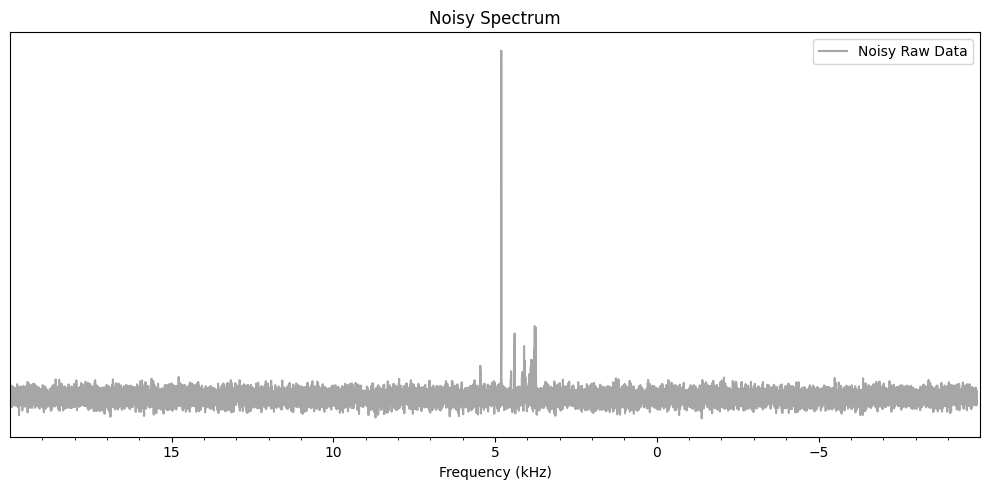

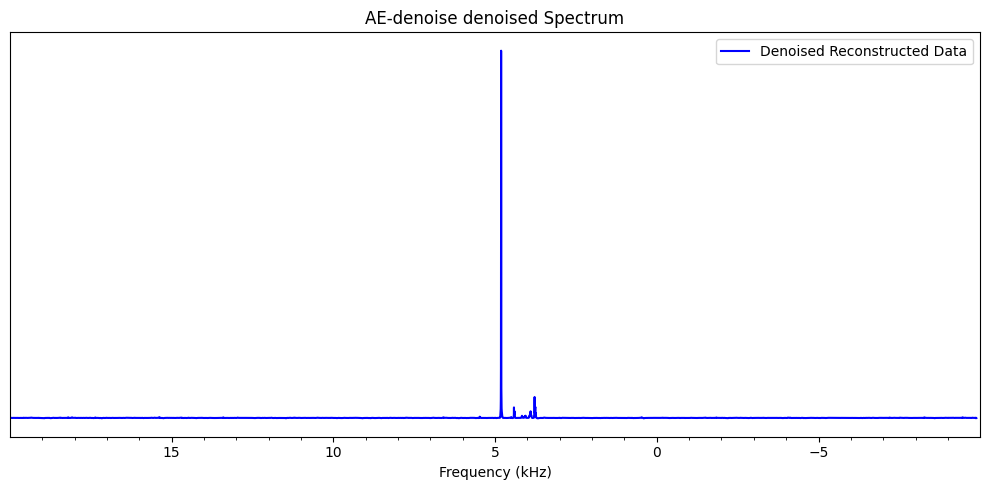

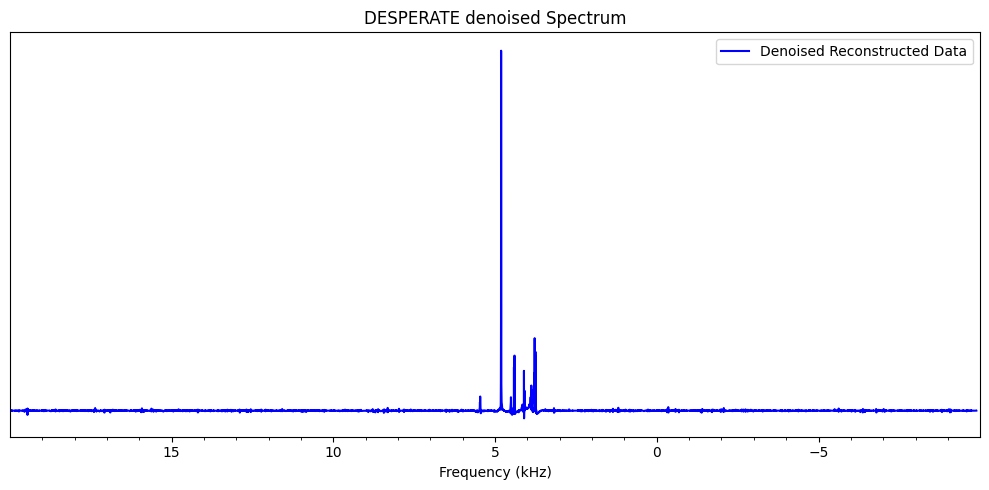

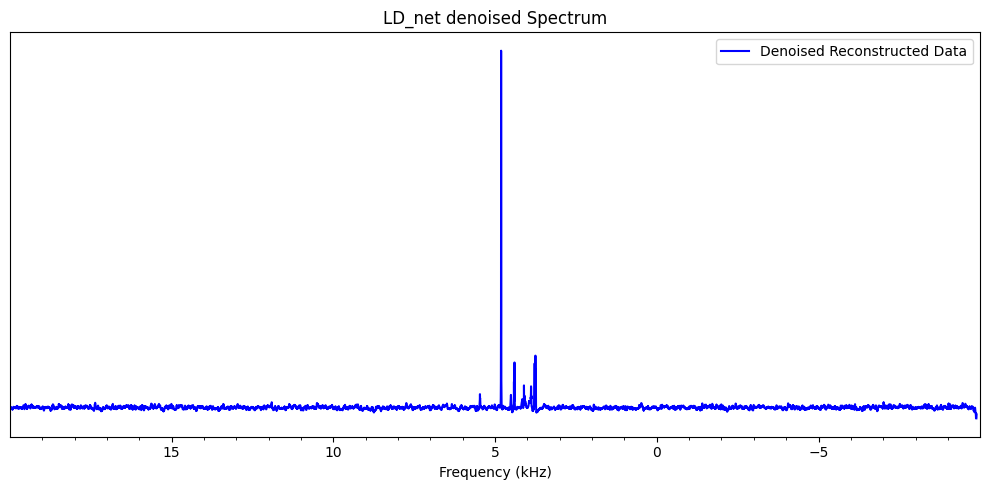

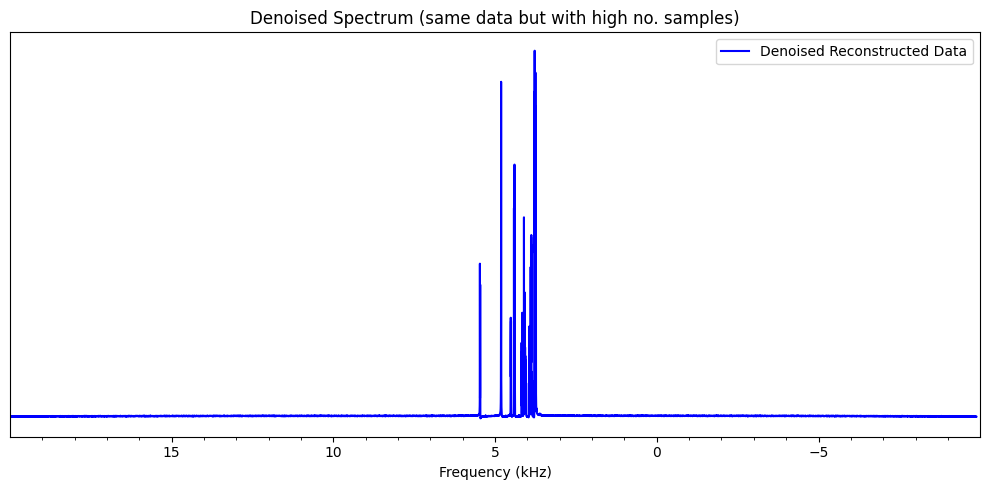

In [14]:

plt.figure(1, figsize=(10, 5))
plt.plot(frq_cropped[:fn], cropped_data[::-1], color='gray', alpha=0.7, label='Noisy Raw Data')
plt.xlim(max(frq_cropped), min(frq_cropped))
plt.title('Noisy Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()

ae_fn = len(ae_denoised_data)
plt.figure(2, figsize=(10, 5))
plt.plot(frq_cropped[:ae_fn], ae_denoised_data[:ae_fn][::-1], color='blue', label='Denoised Reconstructed Data')
plt.xlim(max(frq_cropped), min(frq_cropped))
plt.title('AE-denoise denoised Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()


plt.figure(3, figsize=(10, 5))
plt.plot(frq_cropped[:ae_fn], specrecon[:ae_fn][::-1], color='blue', label='Denoised Reconstructed Data')
plt.xlim(max(frq_cropped), min(frq_cropped))
plt.title('DESPERATE denoised Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()


plt.figure(4, figsize=(10, 5))
plt.plot(frq_cropped[:ae_fn], output_ld[:ae_fn][::-1], color='blue', label='Denoised Reconstructed Data')
plt.xlim(max(frq_cropped), min(frq_cropped))
plt.title('LD_net denoised Spectrum')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()

plt.figure(5, figsize=(10, 5))
plt.plot(frq_cropped[:ae_fn], data_high_samp[:ae_fn][::-1], color='blue', label='Denoised Reconstructed Data')
plt.xlim(max(frq_cropped), min(frq_cropped))
plt.title('Denoised Spectrum (same data but with high no. samples)')
plt.xlabel('Frequency (kHz)')
plt.yticks([])
plt.minorticks_on()
plt.legend(loc='upper right')
plt.tight_layout()


plt.show()


In [15]:
def get_snr(singal, freq1, freq2):
    singal = np.real(singal)
    singal_max = np.max(singal)
    noise = np.real(singal[freq1:freq2])
    snr = singal_max/np.std(noise)
    return snr

In [16]:
snr = get_snr(ae_denoised_data, 1000, 2000)
print(snr)

5110.1914
